# Operator Learning - Fourier Neural Operator (FNO) in Neuromancer

This tutorial demonstrates the use of [FNOs](https://neuraloperator.github.io/dev/theory_guide/fno.html) for solving partial differential equations (PDEs) in the Neuromancer library.

This tutorial demonstrates the complete workflow of training a neural operator: 
1. Creating an FNO model architecture from scratch
2. Setting up `neuromancer.problem.Problem`
3. Training the model with Neuromancer `Trainer`
4. Evaluating predictions and zero-shot super-resolution

Example inspiration: https://github.com/camlab-ethz/AI_Science_Engineering/blob/main/Tutorial%2005%20-%20Operator%20Learing%20-%20Fourier%20Neural%20Operator.ipynb


## Introduction to Fourier Neural Operators (FNO)

The Fourier Neural Operator (FNO) is designed to learn the mapping between functional spaces (operators). Unlike standard neural networks that learn mappings between vectors, FNO learns to approximate an operator $\mathcal{G}$ such that:

$$\mathcal{G}: f \mapsto u$$

### Three-Stage Architecture
The model transforms the input through three distinct stages:
1. Lifting Layer ($P$):
The input function $f(x)$ (which includes the initial field and the spatial grid) is "lifted" into a high-dimensional latent representation $v_0$ using a local transformation:
$$v_0(x) = P(f(x))$$

2. Iterative Fourier Layers ($L$):
The core of the FNO consists of $L$ layers. Each layer $v_\ell \to v_{\ell+1}$ balances global spectral information with local physical information:
$$v_{\ell+1}(x) = \sigma \left( \underbrace{\mathcal{F}^{-1} \left( R_\ell \cdot \mathcal{F}(v_\ell) \right)(x)}_{\text{Global (Spectral Path)}} + \underbrace{W_\ell(v_\ell(x))}_{\text{Local (Pointwise Path)}} \right)$$
- $\mathcal{F}$ / $\mathcal{F}^{-1}$: The Fourier and Inverse Fourier Transforms.
- $R_\ell$: A learnable linear transform applied in the frequency domain (to a truncated set of low-frequency modes).
- $W_\ell$: A learned pointwise linear transformation in physical space (similar to a residual connection).
- $\sigma$: A nonlinear activation function (e.g., Tanh or GeLU).

<img src="https://neuraloperator.github.io/dev/_images/fourier_layer.jpg" width="600"> 

3. Projection Layer ($Q$):
Finally, the latent representation $v_L$ is projected back to the target physical space to obtain the predicted solution:$$u(x) = Q(v_L(x))$$

Key Characteristics
- Grid Independence: Because the spectral weights $R_\ell$ are learned in the frequency domain, a model trained on one resolution can be evaluated on a different resolution.
- Global Context: The FFT allows every point in the domain to "talk" to every other point efficiently ($O(N \log N)$).

### References

[1] [FNO theory guide - neuralop library](https://neuraloperator.github.io/dev/theory_guide/fno.html)

[2] [FNO paper](https://arxiv.org/abs/2010.08895)

[3] [ETH Zurich AI in the Sciences and Engineering](https://camlab-ethz.github.io/ai4s-course/)


## Problem Description - Allen-Cahn Equation

### The Governing Equation
We seek to solve the Allen-Cahn equation in the following form:

$$u_t = \epsilon^2 \Delta u - (u^3 - u)$$

Where:
- $u(x, t)$ is the phase field variable (often representing concentration).
- $\epsilon$ is the parameter controlling the interface width between phases.
- $\Delta u = \nabla^2 u$ represents the diffusion term (Laplacian operator).
- $(u^3 - u)$ is the derivative of the double-well potential, driving the system toward $u = \pm 1$.

Note that the data is generated (see the files *AC_data_input.npy* and *AC_data_output.npy*).

## The operator learning task

Unlike traditional solvers (Finite Difference or Finite Element), the Fourier Neural Operator (FNO) aims to learn the solution operator $\mathcal{G}$ in a resolution-independent manner:

$$\mathcal{G}: f \mapsto u$$

In this notebook, $f$ is the initial condition $u(x, t=0)$, and $u$ is the solution at a later time $t=1$.

$$\mathcal{G}: u(\cdot, t = 0) \mapsto  u(\cdot, t = 1)$$

## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [2]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")

# system imports
import pathlib
import urllib.request


In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Data Loading and Tensor Conversion

We load the pre-generated simulation data from `.npy` files and convert them into PyTorch tensors for training.

* `x_data`: The initial conditions $u(x, 0)$.
* `y_data`: The solution fields $u(x, 1)$. Note that we `unsqueeze` the last dimension to add a channel dimension, resulting in a shape of `(batch, spatial_grid, channel)`.

### Get data of the exact solution
- Data source: (https://raw.githubusercontent.com/camlab-ethz/AI_Science_Engineering/main/datasets)
- Download if needed, save it in `./data/`

In [4]:
# Download once (raw GitHub URLs)
data_dir = pathlib.Path("data/")
data_dir.mkdir(parents=True, exist_ok=True)
base = (
    "https://raw.githubusercontent.com/camlab-ethz/AI_Science_Engineering/main/datasets"
)
for fname in ("AC_data_input.npy", "AC_data_output.npy"):
    url = f"{base}/{fname}"
    dst = data_dir / fname
    if not dst.exists():
        urllib.request.urlretrieve(url, dst)

In [5]:
# Load tensors
x_data = torch.from_numpy(np.load(data_dir / "AC_data_input.npy")).float()
y_data = (
    torch.from_numpy(np.load(data_dir / "AC_data_output.npy")).float().unsqueeze(-1)
)

print(f"Total data shape: {x_data.shape}, {y_data.shape}")

# Splits
n_train, n_val, n_test = 128, 32, 256
input_function_train = x_data[:n_train]
output_function_train = y_data[:n_train]
input_function_val = x_data[n_train : n_train + n_val]
output_function_val = y_data[n_train : n_train + n_val]
input_function_test = x_data[n_train + n_val : n_train + n_val + n_test]
output_function_test = y_data[n_train + n_val : n_train + n_val + n_test]

print(f"Train data shape: {input_function_train.shape}, {output_function_train.shape}")
print(f"Val data shape: {input_function_val.shape}, {output_function_val.shape}")
print(f"Test data shape: {input_function_test.shape}, {output_function_test.shape}")

Total data shape: torch.Size([1000, 1001, 2]), torch.Size([1000, 1001, 1])
Train data shape: torch.Size([128, 1001, 2]), torch.Size([128, 1001, 1])
Val data shape: torch.Size([32, 1001, 2]), torch.Size([32, 1001, 1])
Test data shape: torch.Size([256, 1001, 2]), torch.Size([256, 1001, 1])


### Input and Output Representation

The goal is to learn the operator mapping the system state from the start time to the end time:

* **Input:** The initial condition $u(x, 0)$ representing the phase field at $t=0$.
* **Output:** The evolved solution $u(x, 1)$ at time $t=1$.

### Domain and Boundary Conditions

The Allen-Cahn equation is solved on a one-dimensional spatial domain with periodic boundaries:

* **Spatial Domain:** $x \in [-1, 1]$
* **Time Domain:** $t \in [0, 1]$
* **Boundary Conditions:** Periodic, such that $u(-1, t) = u(1, t)$ for all $t$.

### Visualise dataset

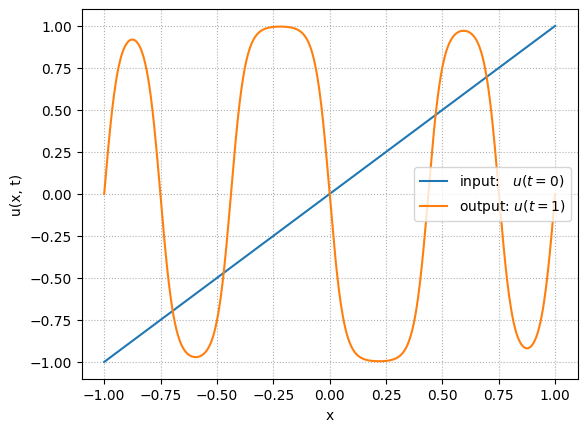

In [6]:
id_sample = 47

plt.plot(
    np.linspace(-1, 1, input_function_train.shape[1]),
    input_function_train[id_sample, :, 0],
    label="input:   $u(t = 0)$",
)
plt.plot(
    np.linspace(-1, 1, input_function_train.shape[1]),
    output_function_train[id_sample, :],
    label="output: $u(t = 1)$",
)
plt.grid(True, which="both", ls=":")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()

### Create Neuromancer datasets for FNO

In [7]:
from neuromancer.dataset import DictDataset

batch_size = 10
# Move data to device
input_function_train = input_function_train.to(device)
output_function_train = output_function_train.to(device)

# Neuromancer DictDatasets
train_ds = DictDataset(
    {"x": input_function_train, "y": output_function_train}, name="train"
)
dev_ds = DictDataset({"x": input_function_val, "y": output_function_val}, name="dev")
test_ds = DictDataset(
    {"x": input_function_test, "y": output_function_test}, name="test"
)

# DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, collate_fn=train_ds.collate_fn
)
dev_loader = torch.utils.data.DataLoader(
    dev_ds, batch_size=batch_size, shuffle=False, collate_fn=dev_ds.collate_fn
)
test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=batch_size, shuffle=False, collate_fn=test_ds.collate_fn
)

## 1D Fourier Neural Operator 

### 1D Spectral/Fourier layer

We first formulate the 1D spectral/fourier layer in `SpectralConv1d` class below. The Fourier layer consists of three steps:
- Fourier transform $\mathcal{F}$ (`torch.fft.rfft`)
- Linear transform on the lower Fourier modes $R$ (`compl_mul1d`)
- Inverse Fourier transform $\mathcal{F}^{-1}$ (`torch.fft.irfft`)

It transforms the signal to the frequency domain, applies learnable complex weights $R$ (`self.weights1`) to the lower modes, and transforms it back:
$$\mathcal{K}(v_l) = \mathcal{F}^{-1} \left( R \cdot \mathcal{F}(v_l) \right)$$

In [8]:
class SpectralConv1d(nn.Module):
    """
    1D Fourier layer. It does FFT, linear transform, and Inverse FFT.
    Taken from: https://colab.research.google.com/drive/1DBZW3AYwzQaxUoXjRxNQml7ClUQFJCR9?usp=sharing
    """

    def __init__(self, in_channels, out_channels, modes1):
        """
        :param in_channels: (int) dimensionality of input
        :param out_channels: (int) dimensionality of output
        :param modes1: (int) number of modes to keep (highest frequencies)
        """
        super(SpectralConv1d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale
            * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat)
        )

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        """
        1D complex multiplication
        :param input: (torch.Tensor, shape=[batch, in_channel, x]) Input in Fourier space
        :param weights: (torch.Tensor, shape=[in_channel, out_channel, x]) Weights in Fourier space
        :return: (torch.Tensor, shape=[batch, out_channel, x]) Output in Fourier space
        """
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        """
        1D Fourier layer forward function
        :param x: (torch.Tensor, shape=[batchsize, in_channels, number of grid points])
        Input in physical space
        :return: (torch.Tensor, shape=[batchsize, out_channels, number of grid points])
        Output in physical space
        """
        batchsize = x.shape[0]
        # use DFT to approximate the fourier transform
        # Compute Fourier coefficients
        x_ft = torch.fft.rfft(x, dim=-1)  # check dim=-1

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-1) // 2 + 1,
            device=x.device,
            dtype=torch.cfloat,
        )
        out_ft[:, :, : self.modes1] = self.compl_mul1d(
            x_ft[:, :, : self.modes1], self.weights1
        )

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1), dim=-1)  # check dim=-1
        return x


### Simple 1D FNO architetcture

The Fourier Neural Operator (FNO) follows a three step procedure.

1. Lifting (Input Processing)

We take the initial state u(x, 0) and attach the grid coordinates x. This 2-channel input is "lifted" into a higher-dimensional latent space.

* $v_0(x) = P(u(x, 0), x)$ , where $P$ is `self.linear_p`, lifting the 2-channel input to a latent dimension (`width`).

2. Fourier Layers

The model uses 3 layers to evolve the data. Each layer has two paths that are added together:

$$v_{l+1} = \sigma(\underbrace{\mathcal{K}(v_l)}_{\text{Spectral Convolution}} + \underbrace{W(v_l)}_{\text{Pointwise Convolution}})$$

* Spectral Convolution ($\mathcal{K}$): Uses `SpectralConv1d`. It converts the signal to "frequencies," keeps the most important ones (modes), multiplies them by learnable weights, and converts them back. This captures long-range patterns or "global" information.
* Pointwise Convolution ($W$): Uses `self.lin0, 1, 2`. This is a $1 \times 1$ convolution (a residual-like connection) that helps recover local information. This becomes useful to recover the high-frequency information that might have been removed by the spectral convolution $\mathcal{K}$.
* Activation ($\sigma$): We use `Tanh()` to introduce non-linearity.

3. Projection (Output Processing)

After the Fourier layers, we need to shrink the data back down from the hidden `width` to a single value for our prediction.

* Step A (`self.linear_q`): Compresses the many hidden channels down to 32. This is our "bottleneck" where the model extracts the most vital features.
* Step B (`self.output_layer`): Final mapping from 32 channels to 1 channel.
* Result: The predicted solution u(x, t=1).

### Data Flow Summary

| Step | Operation | Tensor Shape Change |
| --- | --- | --- |
| **Input** | Start | `[Batch, Space, 2]` |
| **Lift** | `linear_p` | `[Batch, Space, Width]` |
| **Process** | `Fourier Layers` | `[Batch, Width, Space]` |
| **Project** | `linear_q` | `[Batch, Space, 32]` |
| **Output** | `output_layer` | `[Batch, Space, 1]` |


In [9]:
class FNO1d(nn.Module):
    """
    The overall network. It contains 4 layers of the Fourier layer.
    1. Lift the input to the desire channel dimension by self.fc0 .
    2. 4 layers of the integral operators u' = (W + K)(u).
        W defined by self.w; K defined by self.conv .
    3. Project from the channel space to the output space by self.fc1 and self.fc2 .
    """

    def __init__(self, modes, width):
        """
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """
        super(FNO1d, self).__init__()

        self.modes1 = modes
        self.width = width
        self.padding = 1  # pad the domain if input is non-periodic
        self.linear_p = nn.Linear(
            2, self.width
        )  # input channel is 2: (u0(x), x) --> GRID IS INCLUDED!

        self.spect1 = SpectralConv1d(self.width, self.width, self.modes1)
        self.spect2 = SpectralConv1d(self.width, self.width, self.modes1)
        self.spect3 = SpectralConv1d(self.width, self.width, self.modes1)
        self.lin0 = nn.Conv1d(self.width, self.width, 1)
        self.lin1 = nn.Conv1d(self.width, self.width, 1)
        self.lin2 = nn.Conv1d(self.width, self.width, 1)

        # The first part of the projection (Width -> 32)
        self.linear_q = nn.Linear(self.width, 32)
        # The final part of the projection (32 -> 1)
        self.output_layer = nn.Linear(32, 1)

        self.activation = torch.nn.Tanh()

    def fourier_layer(self, x, spectral_layer, conv_layer):
        """
        :param x: (torch.Tensor, shape=[batchsize, in_channels, number of grid points]) Input in physical space
        :param spectral_layer: (nn.Module) Spectral convolutional layer
        :param conv_layer: (nn.Module) Pointwise convolutional layer
        :return: (torch.Tensor, shape=[batchsize, out_channels, number of grid points]) Output in physical space
        """
        return self.activation(spectral_layer(x) + conv_layer(x))

    def linear_layer(self, x, linear_transformation):
        return self.activation(linear_transformation(x))

    def forward(self, x):
        # grid = self.get_grid(x.shape, x.device)
        # x = torch.cat((x, grid), dim=-1)
        x = self.linear_p(x)
        # 1. Prepare for Linear layers
        # Fourier layers use (Batch, Channels, Space),
        # but Linear layers need (Batch, Space, Channels)
        x = x.permute(0, 2, 1)

        # x = F.pad(x, [0, self.padding])  # pad the domain if input is non-periodic

        x = self.fourier_layer(x, self.spect1, self.lin0)
        x = self.fourier_layer(x, self.spect2, self.lin1)
        x = self.fourier_layer(x, self.spect3, self.lin2)

        # x = x[..., :-self.padding]  # pad the domain if input is non-periodic
        # This maps 'width' channels down to 32 and applies Tanh
        x = x.permute(0, 2, 1)

        x = self.linear_layer(x, self.linear_q)
        x = self.output_layer(x)
        return x


In [10]:
# initialise FNO model
modes = 16
width = 64
fno_model = FNO1d(modes, width).to(device)  # model

In [11]:
from neuromancer.system import Node

# symbolic wrapper of the FNO
fno_node = Node(fno_model, ["x"], ["y_fno"], name="fno_model")

In [12]:
print("symbolic inputs  of the fno_node:", fno_node.input_keys)
print("symbolic outputs of the fno_node:", fno_node.output_keys)

symbolic inputs  of the fno_node: ['x']
symbolic outputs of the fno_node: ['y_fno']


In [13]:
# check device for train data
print(train_ds.datadict["y"].device)
# Check shapes match (Input vs Forward Pass Output)
print(f"Input training shape: {train_ds.datadict['y'].shape}")
print(f"Forward Pass on Train data shape: {fno_node(train_ds.datadict)['y_fno'].shape}")

cuda:0
Input training shape: torch.Size([128, 1001, 1])


Forward Pass on Train data shape: torch.Size([128, 1001, 1])


# Generate MSE loss for loss evaluation 
We use L2 loss for training and evaluation
MSE loss

$$
\|y - y_h\|_{L^2(\Omega)}^2.
$$

Approach 1: Formulate the MSE loss definition with simple Neuromancer wrappers. Apply constraints on `variable` 

In [14]:
from neuromancer.constraint import variable

# Inputs from your datadict
y_true = variable("y")
y_hat_fno = variable("y_fno")

# Value (L2) match and gradient (L2) matches; ^2 sets the L2 norm
val_constraint = (y_hat_fno == y_true) ^ 2
val_constraint.update_name("l2_value")


Approach 2: Wrap the residuals with `Objective` and minimise 

In [15]:
from neuromancer.constraint import Objective

# Approach 2: Using Objective
residual_l2 = y_hat_fno - y_true
l2_obj = Objective(residual_l2**2, metric=torch.mean, name="l2_loss")

### Setup FNO problem and Trainer 

In [16]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
objectives_fno = [val_constraint]  # Approach 1
# objectives_fno = [l2_obj]  # Approach 2
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem_fno = Problem(nodes=[fno_node], loss=loss_fno)

### Show problem FNO

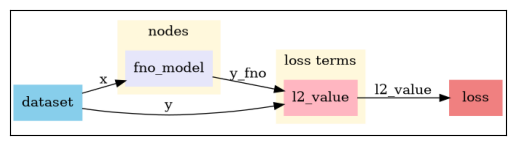

In [17]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem_fno.show()

### Train FNO purely data driven - using 20 samples of 16 x 16 data

In [18]:
from neuromancer.trainer import Trainer
from neuromancer.callbacks import LossHistoryCallback

# define loss history callback using plots
loss_history_callback = LossHistoryCallback(plots_dir=None, show=True)

learning_rate = 0.001
epochs = 50  # = 250
# step_size = 50
# gamma = 0.5
epoch_verbose = 10  # print loss/display loss plot when this many epochs have occurred
warmup = 10  # number of epochs to wait before enacting early stopping policy
patience = 0  # number of epochs with no improvement in eval metric to allow before early stopping

optimizer = torch.optim.Adam(
    problem_fno.parameters(), lr=learning_rate, weight_decay=1e-5
)


In [19]:
# define trainer
trainer = Trainer(
    problem_fno.to(device),
    train_data=train_loader,
    dev_data=dev_loader,
    test_data=test_loader,
    optimizer=optimizer,
    logger=None,
    callback=loss_history_callback,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="test_loss",
    eval_metric="dev_loss",
    warmup=warmup,
    device=device,
)

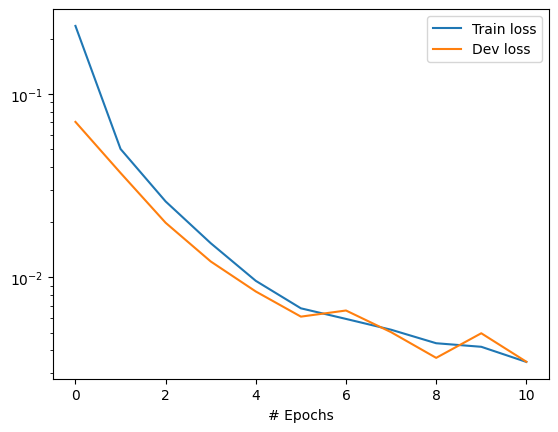

Early stopping!!!


<All keys matched successfully>

In [20]:
# Train FNO
best_model = trainer.train()

# load best trained model
problem_fno.load_state_dict(best_model)

## Visualizing predictions

In [21]:
# evaluate trained FNO on test data
fno_out = problem_fno.nodes[0].cpu()
fno_model_out = fno_out(test_ds.datadict)  # now on 32x32 grid

# evaluate forward pass on the train data
fno_model_out["y_fno"].shape

torch.Size([256, 1001, 1])

Relative L2 error:  4.095366477966309


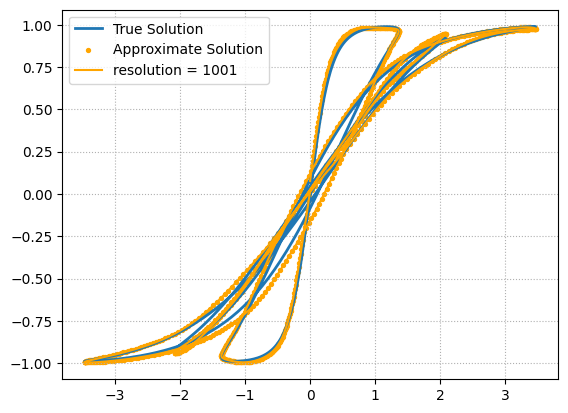

In [22]:
idx_data = 59
fno_eval = problem_fno.nodes[0].to(device)  # or .cpu() if you want plotting on CPU

sample = test_ds[idx_data]
x_n = sample["x"].unsqueeze(0).to(device)  # [1, 1001, 2]
y_true = sample["y"].unsqueeze(0).to(device)  # [1, 1001, 1]

with torch.no_grad():
    y_pred = fno_eval({"x": x_n})["y_fno"]  # [1, 1001, 1]

# Move to CPU for plotting
x_grid = x_n[0, :, 1].detach().cpu()  # spatial grid
y_true_plot = y_true[0, :, 0].detach().cpu()
y_pred_plot = y_pred[0, :, 0].detach().cpu()

res = y_true.shape[1]

plt.figure()
plt.grid(True, which="both", ls=":")
plt.plot(x_grid, y_true_plot, label="True Solution", c="C0", lw=2)
plt.scatter(x_grid, y_pred_plot, label="Approximate Solution", s=8, c="orange")
plt.plot(x_grid, y_pred_plot, color="orange", label=f"resolution = {res}")

p = 2
err = (
    torch.mean((y_true_plot - y_pred_plot).abs() ** p)
    / torch.mean(y_true_plot.abs() ** p)
) ** (1 / p) * 100
print("Relative L2 error: ", err.item())
plt.legend()


### Resolution invariance

We subsample the data 10x to see how the prediction looks like at a different resolution

Relative L2 error:  5.789954662322998


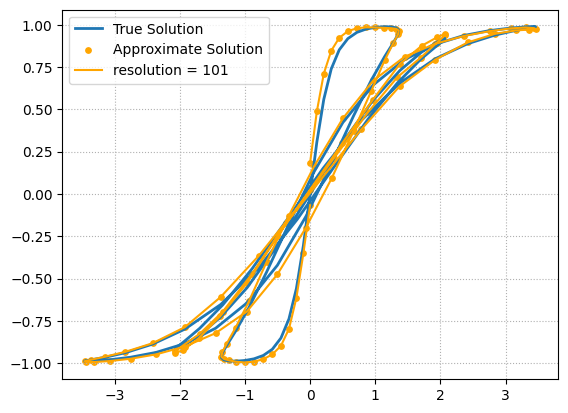

In [23]:
subsample = 10
# idx_data = 12
fno_eval = problem_fno.nodes[0].to(device)

# Take one sample from DictDataset and subsample in space
sample = test_ds[idx_data]
x_n = sample["x"][::subsample].unsqueeze(0).to(device)  # [1, res, 2]
y_true = sample["y"][::subsample].unsqueeze(0).to(device)  # [1, res, 1]
res = y_true.shape[1]

with torch.no_grad():
    y_pred = fno_eval({"x": x_n})["y_fno"]  # [1, res, 1]

# For plotting
x_grid = x_n[0, :, 1].detach().cpu()
y_true_plot = y_true[0, :, 0].detach().cpu()
y_pred_plot = y_pred[0, :, 0].detach().cpu()

plt.figure()
plt.grid(True, which="both", ls=":")
plt.plot(x_grid, y_true_plot, label="True Solution", c="C0", lw=2)
plt.scatter(x_grid, y_pred_plot, label="Approximate Solution", s=15, color="orange")
plt.plot(x_grid, y_pred_plot, color="orange", label=f"resolution = {res}")

p = 2
err = (
    torch.mean((y_true_plot - y_pred_plot).abs() ** p)
    / torch.mean(y_true_plot.abs() ** p)
) ** (1 / p) * 100
print("Relative L2 error: ", err.item())
plt.legend()
